José Herrera Ortiz - Universidad Pontificia Comillas ICAI

# Task 1: Classification

In this notebook, we address the supervised classification task of predicting the student's final academic status (`objetivo`).

We consider two scenarios:

1. **Early prediction**: using only information available before university academic performance is observed.
2. **Prediction after first semester**: using the same information plus first-semester academic variables.

Since this is a **multiclass classification problem** (`Abandono`, `Matriculado`, `Graduado`), model evaluation will later focus on metrics such as macro-F1, balanced accuracy and accuracy.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from utils_project import (
    load_data,
    get_project_variables,
    build_classification_data,
    split_feature_types,
    create_preprocessor
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

from sklearn.metrics import confusion_matrix

Load data and variable groups

In [2]:
df = load_data("../data/rendimiento_estudiantes.csv")
variables = get_project_variables(df)

print("Dataset shape:", df.shape)
print("\nAvailable keys in variables dictionary:")
for key in variables.keys():
    print("-", key)

Dataset shape: (4424, 37)

Available keys in variables dictionary:
- classification_target
- regression_target
- demographic_features
- access_features
- socioeconomic_features
- macro_features
- first_sem_features
- second_sem_features
- initial_features
- continuous_features
- discrete_features
- categorical_features
- classification_features_early
- classification_features_first_sem
- regression_features
- regression_excluded_features
- unsupervised_features


Build classification datasets

In [3]:
X_early, y = build_classification_data(df, variables, scenario="early")
X_first_sem, y = build_classification_data(df, variables, scenario="first_sem")

print("Early scenario shape:", X_early.shape)
print("First-semester scenario shape:", X_first_sem.shape)
print("Target shape:", y.shape)

Early scenario shape: (4424, 24)
First-semester scenario shape: (4424, 30)
Target shape: (4424,)


Check target distributions

Target counts:


objetivo
graduado       2209
abandono       1421
matriculado     794
Name: count, dtype: int64


Target proportions:


objetivo
graduado       0.499
abandono       0.321
matriculado    0.179
Name: proportion, dtype: float64

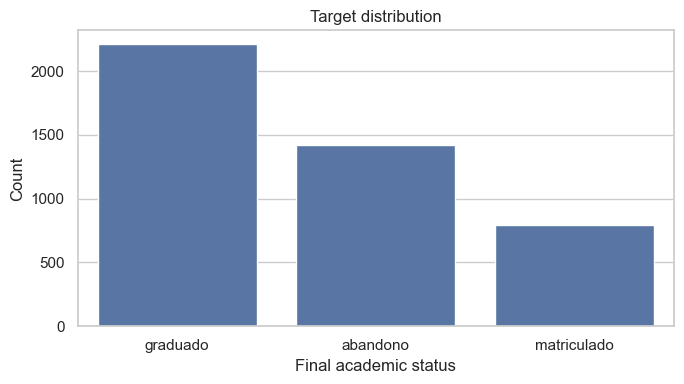

In [4]:
print("Target counts:")
display(y.value_counts())

print("\nTarget proportions:")
display(y.value_counts(normalize=True).round(3))

plt.figure(figsize=(7, 4))
sns.countplot(x=y, order=y.value_counts().index)
plt.title("Target distribution")
plt.xlabel("Final academic status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
def plot_confusion_matrix_custom(y_true, y_pred, title, labels=None, figsize=(8, 6)):
    if labels is None:
        labels = sorted(list(set(y_true) | set(y_pred)))

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="viridis",
        xticklabels=labels,
        yticklabels=labels,
        cbar=True
    )
    plt.title(title, fontsize=18)
    plt.xlabel("Predicted label", fontsize=14)
    plt.ylabel("True label", fontsize=14)
    plt.xticks(rotation=25, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

Train/test splits for both scenarios

In [6]:
X_train_early, X_test_early, y_train_early, y_test_early = train_test_split(
    X_early,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_first_sem, X_test_first_sem, y_train_first_sem, y_test_first_sem = train_test_split(
    X_first_sem,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Early scenario")
print("Train:", X_train_early.shape, y_train_early.shape)
print("Test :", X_test_early.shape, y_test_early.shape)

print("\nFirst-semester scenario")
print("Train:", X_train_first_sem.shape, y_train_first_sem.shape)
print("Test :", X_test_first_sem.shape, y_test_first_sem.shape)

Early scenario
Train: (3539, 24) (3539,)
Test : (885, 24) (885,)

First-semester scenario
Train: (3539, 30) (3539,)
Test : (885, 30) (885,)


Split feature types

In [7]:
numeric_early, categorical_early = split_feature_types(X_train_early)
numeric_first_sem, categorical_first_sem = split_feature_types(X_train_first_sem)

print("Early scenario")
print("Numeric features:", numeric_early)
print("Categorical features:", categorical_early)

print("\nFirst-semester scenario")
print("Numeric features:", numeric_first_sem)
print("Categorical features:", categorical_first_sem)

Early scenario
Numeric features: ['edad_al_matricularse', 'orden_solicitud', 'nota_cualificacion_previa', 'nota_admision', 'tasa_desempleo', 'tasa_inflacion', 'pib']
Categorical features: ['estado_civil', 'nacionalidad', 'genero', 'desplazado', 'internacional', 'necesidades_educativas_especiales', 'modo_solicitud', 'curso', 'asistencia_diurna_vespertina', 'cualificacion_previa', 'cualificacion_madre', 'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre', 'deudor', 'matricula_al_dia', 'becado']

First-semester scenario
Numeric features: ['edad_al_matricularse', 'orden_solicitud', 'nota_cualificacion_previa', 'nota_admision', 'tasa_desempleo', 'tasa_inflacion', 'pib', 'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas', 'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion']
Categorical features: ['estado_civil', 'nacionalidad', 'genero', 'desplazado', 'internacional', 'necesidades_educativas_especiales', 'modo

Create prepocessors

In [8]:
preprocessor_early = create_preprocessor(
    numeric_features=numeric_early,
    categorical_features=categorical_early,
    scale_numeric=True
)

preprocessor_first_sem = create_preprocessor(
    numeric_features=numeric_first_sem,
    categorical_features=categorical_first_sem,
    scale_numeric=True
)

print("Preprocessors created successfully.")

Preprocessors created successfully.


Check

In [9]:
print("Early scenario")
print("Number of numeric features:", len(numeric_early))
print("Number of categorical features:", len(categorical_early))
print("Total raw features:", X_train_early.shape[1])

print("\nFirst-semester scenario")
print("Number of numeric features:", len(numeric_first_sem))
print("Number of categorical features:", len(categorical_first_sem))
print("Total raw features:", X_train_first_sem.shape[1])

Early scenario
Number of numeric features: 7
Number of categorical features: 17
Total raw features: 24

First-semester scenario
Number of numeric features: 13
Number of categorical features: 17
Total raw features: 30


Imports

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# 1. Baseline model (Logistic Regression)

## 1.1. Early scenario

Pipeline

In [11]:
pipe_logreg_early = Pipeline([
    ("preprocessor", preprocessor_early),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

Train

In [12]:
pipe_logreg_early.fit(X_train_early, y_train_early)

Predict

In [13]:
y_pred_early = pipe_logreg_early.predict(X_test_early)

Evaluate

=== Logistic Regression (Early) ===
Accuracy: 0.6056497175141243
Balanced accuracy: 0.5867897940399542
F1 macro: 0.5739940207109363

Classification report:
              precision    recall  f1-score   support

    abandono       0.67      0.56      0.61       284
    graduado       0.77      0.66      0.71       442
 matriculado       0.32      0.54      0.40       159

    accuracy                           0.61       885
   macro avg       0.59      0.59      0.57       885
weighted avg       0.66      0.61      0.62       885



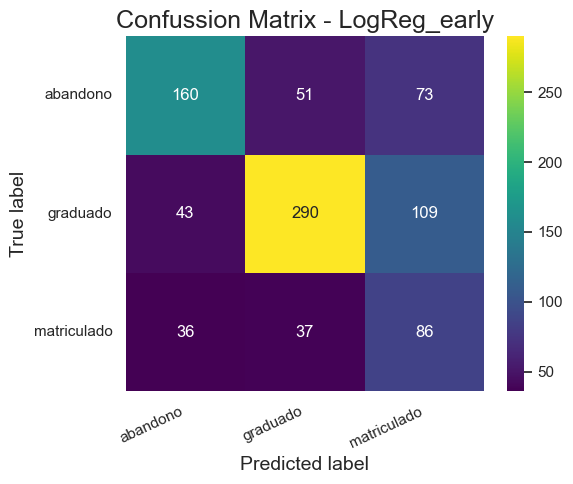

In [14]:
print("=== Logistic Regression (Early) ===")

print("Accuracy:", accuracy_score(y_test_early, y_pred_early))
print("Balanced accuracy:", balanced_accuracy_score(y_test_early, y_pred_early))
print("F1 macro:", f1_score(y_test_early, y_pred_early, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_early, y_pred_early))

class_labels = ["abandono", "graduado", "matriculado"]

plot_confusion_matrix_custom(
    y_test_early,
    y_pred_early,
    title="Confusion Matrix - LogReg_early",
    labels=class_labels,
    figsize=(6, 5))

## 1.2. First semester

Pipeline

In [15]:
pipe_logreg_first_sem = Pipeline([
    ("preprocessor", preprocessor_first_sem),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

Fit

In [16]:
pipe_logreg_first_sem.fit(X_train_first_sem, y_train_first_sem)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Predict

In [17]:
y_pred_first_sem = pipe_logreg_first_sem.predict(X_test_first_sem)

Evaluate

=== Logistic Regression (First-semester scenario) ===
Accuracy: 0.7096045197740113
Balanced accuracy: 0.6673323328800028
F1 macro: 0.6621675849244492

Classification report:
              precision    recall  f1-score   support

    abandono       0.79      0.68      0.73       284
    graduado       0.84      0.79      0.82       442
 matriculado       0.38      0.53      0.44       159

    accuracy                           0.71       885
   macro avg       0.67      0.67      0.66       885
weighted avg       0.74      0.71      0.72       885



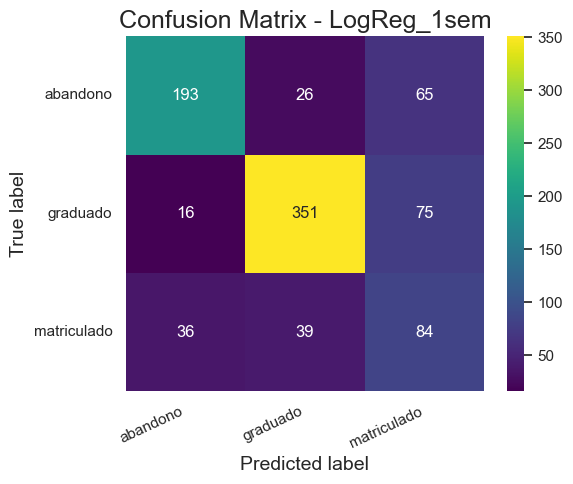

In [18]:
print("=== Logistic Regression (First-semester scenario) ===")
print("Accuracy:", accuracy_score(y_test_first_sem, y_pred_first_sem))
print("Balanced accuracy:", balanced_accuracy_score(y_test_first_sem, y_pred_first_sem))
print("F1 macro:", f1_score(y_test_first_sem, y_pred_first_sem, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_first_sem, y_pred_first_sem))

plot_confusion_matrix_custom(
    y_test_first_sem,
    y_pred_first_sem,
    title="Confusion Matrix - LogReg_1sem",
    labels=class_labels,
    figsize=(6, 5)
)

# 2. Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

## 2.1. Early scenario

Pipeline

In [20]:
pipe_rf_early = Pipeline([
    ("preprocessor", preprocessor_early),
    ("model", RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

Fit + predict

In [21]:
pipe_rf_early.fit(X_train_early, y_train_early)
y_pred_rf_early = pipe_rf_early.predict(X_test_early)

Metrics + Confusion Matrix

=== Random Forest (Early scenario) ===
Accuracy: 0.631638418079096
Balanced accuracy: 0.5579957638390366
F1 macro: 0.5598657712221587

Classification report:
              precision    recall  f1-score   support

    abandono       0.64      0.63      0.63       284
    graduado       0.71      0.76      0.73       442
 matriculado       0.35      0.29      0.32       159

    accuracy                           0.63       885
   macro avg       0.56      0.56      0.56       885
weighted avg       0.62      0.63      0.63       885



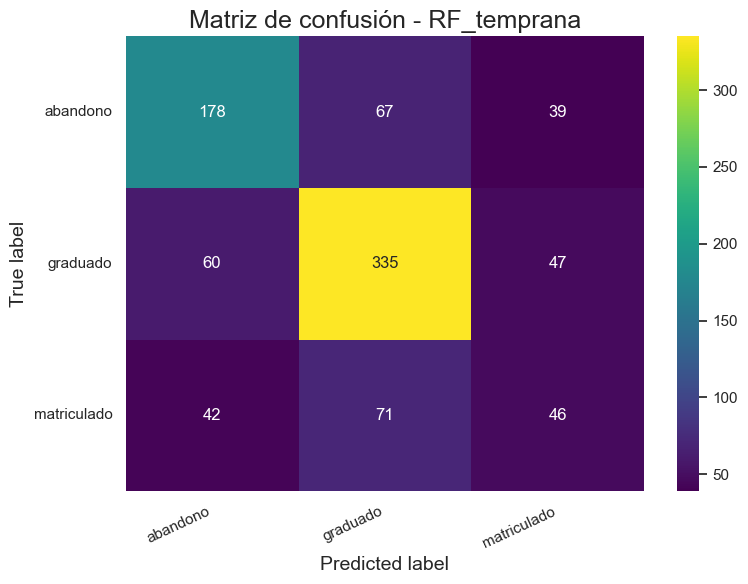

In [22]:
print("=== Random Forest (Early scenario) ===")
print("Accuracy:", accuracy_score(y_test_early, y_pred_rf_early))
print("Balanced accuracy:", balanced_accuracy_score(y_test_early, y_pred_rf_early))
print("F1 macro:", f1_score(y_test_early, y_pred_rf_early, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_early, y_pred_rf_early))

plot_confusion_matrix_custom(
    y_test_early,
    y_pred_rf_early,
    title="Confusion Matrix - RF_early",
    labels=class_labels,
    figsize=(8, 6)
)

## 2.2. First semester scenario

Pipeline

In [23]:
pipe_rf_first_sem = Pipeline([
    ("preprocessor", preprocessor_first_sem),
    ("model", RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

Fit + predict

In [24]:
pipe_rf_first_sem.fit(X_train_first_sem, y_train_first_sem)
y_pred_rf_first_sem = pipe_rf_first_sem.predict(X_test_first_sem)

Metrics + Confusion Matrix

=== Random Forest (First-semester scenario) ===
Accuracy: 0.7322033898305085
Balanced accuracy: 0.6510394934563698
F1 macro: 0.6581283508353745

Classification report:
              precision    recall  f1-score   support

    abandono       0.79      0.69      0.73       284
    graduado       0.78      0.89      0.83       442
 matriculado       0.45      0.38      0.41       159

    accuracy                           0.73       885
   macro avg       0.67      0.65      0.66       885
weighted avg       0.72      0.73      0.72       885



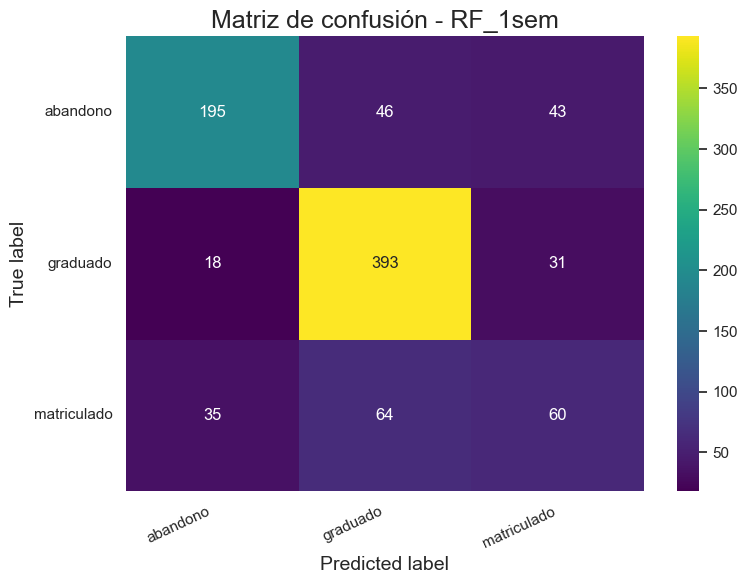

In [25]:
print("=== Random Forest (First-semester scenario) ===")
print("Accuracy:", accuracy_score(y_test_first_sem, y_pred_rf_first_sem))
print("Balanced accuracy:", balanced_accuracy_score(y_test_first_sem, y_pred_rf_first_sem))
print("F1 macro:", f1_score(y_test_first_sem, y_pred_rf_first_sem, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_first_sem, y_pred_rf_first_sem))

plot_confusion_matrix_custom(
    y_test_first_sem,
    y_pred_rf_first_sem,
    title="Confusion Matrix - RF_1sem",
    labels=class_labels,
    figsize=(8, 6)
)

# 3. Cross Validation

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro"
}

models_clf = {
    "LogReg_early": (pipe_logreg_early, X_train_early, y_train_early),
    "LogReg_1sem": (pipe_logreg_first_sem, X_train_first_sem, y_train_first_sem),
    "RF_early": (pipe_rf_early, X_train_early, y_train_early),
    "RF_1sem": (pipe_rf_first_sem, X_train_first_sem, y_train_first_sem),
}

In [28]:
cv_results = []

for name, (model, Xtr, ytr) in models_clf.items():
    scores = cross_validate(
        model,
        Xtr,
        ytr,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "cv_macro_f1_mean": scores["test_macro_f1"].mean()
    })

cv_results = pd.DataFrame(cv_results).sort_values("cv_macro_f1_mean", ascending=False)
cv_results

,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_macro_f1_mean
3,RF_1sem,0.741457,0.664245,0.671823
1,LogReg_1sem,0.712630,0.678748,0.671251
2,RF_early,0.639728,0.560608,0.563233
0,LogReg_early,0.592253,0.573065,0.562028


# 4. Test results' final table, to compare with cross validation

Test results of the 4 models

In [29]:
test_results = pd.DataFrame([
    {
        "model": "LogReg_early",
        "test_accuracy": accuracy_score(y_test_early, y_pred_early),
        "test_balanced_accuracy": balanced_accuracy_score(y_test_early, y_pred_early),
        "test_macro_f1": f1_score(y_test_early, y_pred_early, average="macro"),
    },
    {
        "model": "LogReg_1sem",
        "test_accuracy": accuracy_score(y_test_first_sem, y_pred_first_sem),
        "test_balanced_accuracy": balanced_accuracy_score(y_test_first_sem, y_pred_first_sem),
        "test_macro_f1": f1_score(y_test_first_sem, y_pred_first_sem, average="macro"),
    },
    {
        "model": "RF_early",
        "test_accuracy": accuracy_score(y_test_early, y_pred_rf_early),
        "test_balanced_accuracy": balanced_accuracy_score(y_test_early, y_pred_rf_early),
        "test_macro_f1": f1_score(y_test_early, y_pred_rf_early, average="macro"),
    },
    {
        "model": "RF_1sem",
        "test_accuracy": accuracy_score(y_test_first_sem, y_pred_rf_first_sem),
        "test_balanced_accuracy": balanced_accuracy_score(y_test_first_sem, y_pred_rf_first_sem),
        "test_macro_f1": f1_score(y_test_first_sem, y_pred_rf_first_sem, average="macro"),
    },
])

test_results = test_results.sort_values("test_macro_f1", ascending=False)
test_results.round(4)

,model,test_accuracy,test_balanced_accuracy,test_macro_f1
1,LogReg_1sem,0.7096,0.6673,0.6622
3,RF_1sem,0.7322,0.6510,0.6581
0,LogReg_early,0.6056,0.5868,0.5740
2,RF_early,0.6316,0.5580,0.5599


Test + Cross Validation

In [30]:
final_results = cv_results.merge(test_results, on="model", how="inner")

final_results = final_results[
    [
        "model",
        "cv_accuracy_mean",
        "cv_balanced_accuracy_mean",
        "cv_macro_f1_mean",
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
    ]
].sort_values("test_macro_f1", ascending=False)

final_results.round(4)

,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_macro_f1_mean,test_accuracy,test_balanced_accuracy,test_macro_f1
1,LogReg_1sem,0.7126,0.6787,0.6713,0.7096,0.6673,0.6622
0,RF_1sem,0.7415,0.6642,0.6718,0.7322,0.6510,0.6581
3,LogReg_early,0.5923,0.5731,0.5620,0.6056,0.5868,0.5740
2,RF_early,0.6397,0.5606,0.5632,0.6316,0.5580,0.5599


In [31]:
best_test_model = final_results.iloc[0]["model"]
best_cv_model = final_results.sort_values("cv_macro_f1_mean", ascending=False).iloc[0]["model"]

print("Best model by test macro-F1:", best_test_model)
print("Best model by CV macro-F1:", best_cv_model)

Best model by test macro-F1: LogReg_1sem
Best model by CV macro-F1: RF_1sem


# 5. Analyse LogReg_1sem

In [32]:
from utils_project import get_feature_names_from_preprocessor

In [33]:
feature_names_first_sem = get_feature_names_from_preprocessor(
    preprocessor=pipe_logreg_first_sem.named_steps["preprocessor"],
    numeric_features=numeric_first_sem,
    categorical_features=categorical_first_sem
)

len(feature_names_first_sem)

238

In [34]:
logreg_model_1sem = pipe_logreg_first_sem.named_steps["model"]

coef_df = pd.DataFrame(
    logreg_model_1sem.coef_,
    index=logreg_model_1sem.classes_,
    columns=feature_names_first_sem
)

In [35]:
for class_name in coef_df.index:
    print(f"\n==============================")
    print(f"CLASS: {class_name}")
    print(f"Top positive coefficients")
    display(coef_df.loc[class_name].sort_values(ascending=False).head(10).to_frame("coefficient"))

    print(f"Top negative coefficients")
    display(coef_df.loc[class_name].sort_values(ascending=True).head(10).to_frame("coefficient"))


CLASS: abandono
Top positive coefficients


,coefficient
ocupacion_padre_otra_situacion,1.329372
ocupacion_madre_estudiante,1.147681
matricula_al_dia_no,0.942459
curso_educacion_basica,0.912894
cualificacion_previa_educacion_superior_licenciatura,0.776357
asignaturas_1sem_matriculadas,0.773543
cualificacion_padre_curso_tecnico_profesional,0.763288
cualificacion_padre_educacion_superior_grado_1er_ciclo,0.702041
ocupacion_madre_operadoras_de_instalaciones_y_maquinaria_y_montadoras,0.700476
cualificacion_madre_educacion_superior_grado_1er_ciclo,0.682735


Top negative coefficients


,coefficient
asignaturas_1sem_aprobadas,-1.781483
cualificacion_madre_educacion_superior_master,-1.235320
modo_solicitud_estudiante_internacional_licenciatura,-1.054586
curso_animacion_y_diseno_multimedia,-1.047807
ocupacion_madre_personal_de_limpieza,-1.033436
matricula_al_dia_si,-0.864661
nacionalidad_mozambiquena,-0.722427
nacionalidad_caboverdiana,-0.646986
ocupacion_madre_tecnicas_intermedias_de_servicios_juridicos_sociales_deportivos_culturales_y_similares,-0.609653
cualificacion_madre_educacion_superior_licenciatura,-0.604463



CLASS: graduado
Top positive coefficients


,coefficient
asignaturas_1sem_aprobadas,2.206814
curso_servicio_social,0.871408
curso_animacion_y_diseno_multimedia,0.851221
ocupacion_madre_otra_situacion,0.837532
modo_solicitud_estudiante_internacional_licenciatura,0.765218
ocupacion_madre_otro_personal_de_apoyo_administrativo,0.691682
matricula_al_dia_si,0.657845
cualificacion_padre_7o_ano_antiguo,0.617322
cualificacion_padre_educacion_superior_master_2o_ciclo,0.577884
curso_servicio_social_nocturno,0.541631


Top negative coefficients


,coefficient
asignaturas_1sem_matriculadas,-1.047538
curso_tecnologias_de_produccion_de_biocombustibles,-0.955730
curso_educacion_basica,-0.864697
ocupacion_madre_operadoras_de_instalaciones_y_maquinaria_y_montadoras,-0.862524
curso_ingenieria_informatica,-0.764059
matricula_al_dia_no,-0.690306
estado_civil_separado/a_legalmente,-0.666646
cualificacion_padre_curso_de_especializacion_tecnologica,-0.645808
cualificacion_padre_desconocido,-0.620856
ocupacion_padre_profesionales_de_la_salud,-0.552325



CLASS: matriculado
Top positive coefficients


,coefficient
cualificacion_madre_educacion_superior_master,0.928819
curso_ingenieria_informatica,0.882103
cualificacion_madre_educacion_superior_licenciatura,0.841390
ocupacion_madre_tecnicas_y_profesionales_intermedias_de_salud,0.777915
cualificacion_padre_curso_de_especializacion_tecnologica,0.771916
ocupacion_madre_tecnicas_intermedias_de_servicios_juridicos_sociales_deportivos_culturales_y_similares,0.744466
modo_solicitud_titular_de_diploma_de_especializacion_tecnologica,0.731805
ocupacion_madre_personal_de_limpieza,0.725003
ocupacion_padre_profesionales_de_la_salud,0.677124
cualificacion_madre_educacion_superior_master_2o_ciclo,0.612687


Top negative coefficients


,coefficient
ocupacion_madre_estudiante,-1.384945
ocupacion_madre_otra_situacion,-1.334086
ocupacion_padre_otra_situacion,-1.127700
cualificacion_madre_12o_ano_no_completado,-0.832209
ocupacion_padre_estudiante,-0.820160
modo_solicitud_ordenanza_854_b_99,-0.709740
ocupacion_padre_otro_personal_de_las_fuerzas_armadas,-0.669975
cualificacion_previa_educacion_superior_grado,-0.625331
cualificacion_madre_curso_superior_especializado,-0.602249
ocupacion_madre_agricultoras_y_trabajadoras_cualificadas_de_agricultura_pesca_y_silvicultura,-0.526395


---------------

In [36]:
selected_features = [
    "asignaturas_1sem_aprobadas",
    "asignaturas_1sem_matriculadas",
    "matricula_al_dia_no",
    "matricula_al_dia_si",
]

selected_classes = ["abandono", "graduado"]

summary_rows = []

for cls in selected_classes:
    for feat in selected_features:
        coef_value = coef_df.loc[cls, feat]
        summary_rows.append({
            "class": cls,
            "feature": feat,
            "coefficient": round(coef_value, 3),
            "effect": "positive" if coef_value > 0 else "negative"
        })

coef_summary_table = pd.DataFrame(summary_rows)
coef_summary_table

,class,feature,coefficient,effect
0,abandono,asignaturas_1sem_aprobadas,-1.781,negative
1,abandono,asignaturas_1sem_matriculadas,0.774,positive
2,abandono,matricula_al_dia_no,0.942,positive
3,abandono,matricula_al_dia_si,-0.865,negative
4,graduado,asignaturas_1sem_aprobadas,2.207,positive
5,graduado,asignaturas_1sem_matriculadas,-1.048,negative
6,graduado,matricula_al_dia_no,-0.690,negative
7,graduado,matricula_al_dia_si,0.658,positive


In [37]:
feature_name_map = {
    "asignaturas_1sem_aprobadas": "Curricular units approved (1st semester)",
    "asignaturas_1sem_matriculadas": "Curricular units enrolled (1st semester)",
    "matricula_al_dia_no": "Tuition fees up to date = No",
    "matricula_al_dia_si": "Tuition fees up to date = Yes",
    "abandono": "Dropout",
    "graduado": "Graduate",
}

coef_summary_pretty = coef_summary_table.copy()
coef_summary_pretty["class"] = coef_summary_pretty["class"].map(feature_name_map)
coef_summary_pretty["feature"] = coef_summary_pretty["feature"].map(feature_name_map)

coef_summary_pretty = coef_summary_pretty.sort_values(
    ["class", "coefficient"],
    ascending=[True, False]
).reset_index(drop=True)

coef_summary_pretty.style.hide(axis="index")

class,feature,coefficient,effect
Dropout,Tuition fees up to date = No,0.942000,positive
Dropout,Curricular units enrolled (1st semester),0.774000,positive
Dropout,Tuition fees up to date = Yes,-0.865000,negative
Dropout,Curricular units approved (1st semester),-1.781000,negative
Graduate,Curricular units approved (1st semester),2.207000,positive
Graduate,Tuition fees up to date = Yes,0.658000,positive
Graduate,Tuition fees up to date = No,-0.690000,negative
Graduate,Curricular units enrolled (1st semester),-1.048000,negative
